# Phase 2b: Lag Feature Engineering
---
 **Purpose:** Construct lagged predictor variables required for the NB-AR model. Twelve weekly rainfall lags, two four-week cumulative rainfall measures, four autoregressive dengue lags, and three seasonal binary indicators are generated.  
**Input:** `phase2_output_dengue_rainfall.csv`  
**Output:** `phase2b_output_with_lags.csv`

## 2b.1 Setup

In [1]:
!pip install -q pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

## 2b.2 Load Input Data

In [2]:
print('Upload: phase2_output_dengue_rainfall.csv')
uploaded = files.upload()
input_file = list(uploaded.keys())[0]
df = pd.read_csv(input_file)
df = df.sort_values(['MOH','Year','Week']).reset_index(drop=True)
print(f'Loaded: {len(df):,} records, columns: {list(df.columns)}')

Upload: phase2_output_dengue_rainfall.csv


Saving phase2_output_dengue_rainfall (13).csv to phase2_output_dengue_rainfall (13).csv
Loaded: 520 records, columns: ['District', 'MOH', 'Week', 'Dengue_Cases', 'Year', 'Weekly_Mean_Rainfall', 'Rainy_Days', 'Max_Daily_Rainfall']


## 2b.3 Rainfall Lag Variables (Lag1–Lag12)

In [3]:
# Weekly rainfall lags — grouped by MOH to avoid cross-area leakage
for lag in range(1, 13):
    df[f'Rainfall_Lag{lag}'] = df.groupby('MOH')['Weekly_Mean_Rainfall'].shift(lag)
print('Created rainfall lags: Rainfall_Lag1 through Rainfall_Lag12')

Created rainfall lags: Rainfall_Lag1 through Rainfall_Lag12


## 2b.4 Cumulative Rainfall Measures

In [4]:
# Four-week cumulative rainfall (sum of previous 4 weekly means)
# Cum4w_Lag1 : rolling 4-week sum ending one week before current
# Cum4w_Lag4 : rolling 4-week sum ending four weeks before current
for moh in df['MOH'].unique():
    mask = df['MOH'] == moh
    df.loc[mask, 'Rainfall_Cum4w_Lag1'] = (
        df.loc[mask, 'Weekly_Mean_Rainfall'].rolling(4).sum().shift(1)
    )
    df.loc[mask, 'Rainfall_Cum4w_Lag4'] = (
        df.loc[mask, 'Weekly_Mean_Rainfall'].rolling(4).sum().shift(4)
    )
print('Created cumulative rainfall: Rainfall_Cum4w_Lag1, Rainfall_Cum4w_Lag4')

Created cumulative rainfall: Rainfall_Cum4w_Lag1, Rainfall_Cum4w_Lag4


## 2b.5 Autoregressive Dengue Lags

In [5]:
# Autoregressive dengue terms — grouped by MOH
for lag in [1, 2, 3, 4]:
    df[f'Dengue_Lag{lag}'] = df.groupby('MOH')['Dengue_Cases'].shift(lag)
print('Created autoregressive terms: Dengue_Lag1 through Dengue_Lag4')

Created autoregressive terms: Dengue_Lag1 through Dengue_Lag4


## 2b.6 Seasonal Indicators

In [6]:
# Sri Lankan monsoon seasons by epidemiological week
# Southwest monsoon (SW):       May–September (weeks 19–39)
# Northeast monsoon (NE):       December–February (weeks 48–52, 1–9)
# Inter-monsoon (Inter):        March–April, October–November

def assign_season(week):
    if 19 <= week <= 39:
        return 'SW'
    elif week >= 48 or week <= 9:
        return 'NE'
    else:
        return 'Inter'

df['Season'] = df['Week'].apply(assign_season)
df['Season_SW'] = (df['Season'] == 'SW').astype(int)
df['Season_NE'] = (df['Season'] == 'NE').astype(int)
df['Season_Inter'] = (df['Season'] == 'Inter').astype(int)

print('Season distribution:')
print(df['Season'].value_counts())

Season distribution:
Season
SW       210
Inter    170
NE       140
Name: count, dtype: int64


## 2b.7 Verification

In [7]:
# Missing-value audit (expected for initial weeks due to shift operations)
print(f'Dataset: {len(df):,} rows × {len(df.columns)} columns')
print('\nMissing values per lag variable (expected for early weeks):')
lag_cols = [c for c in df.columns if c.startswith(('Rainfall_Lag','Rainfall_Cum4w','Dengue_Lag'))]
print(df[lag_cols].isna().sum())

# Complete-case count (for model training)
complete = df.dropna(subset=lag_cols)
print(f'\nComplete cases (all lags available): {len(complete):,}')

Dataset: 520 rows × 30 columns

Missing values per lag variable (expected for early weeks):
Rainfall_Lag1           2
Rainfall_Lag2           4
Rainfall_Lag3           6
Rainfall_Lag4           8
Rainfall_Lag5          10
Rainfall_Lag6          12
Rainfall_Lag7          14
Rainfall_Lag8          16
Rainfall_Lag9          18
Rainfall_Lag10         20
Rainfall_Lag11         22
Rainfall_Lag12         24
Rainfall_Cum4w_Lag1     8
Rainfall_Cum4w_Lag4    14
Dengue_Lag1             2
Dengue_Lag2             4
Dengue_Lag3             6
Dengue_Lag4             8
dtype: int64

Complete cases (all lags available): 496


## 2b.8 Visualisation of Lag Structure

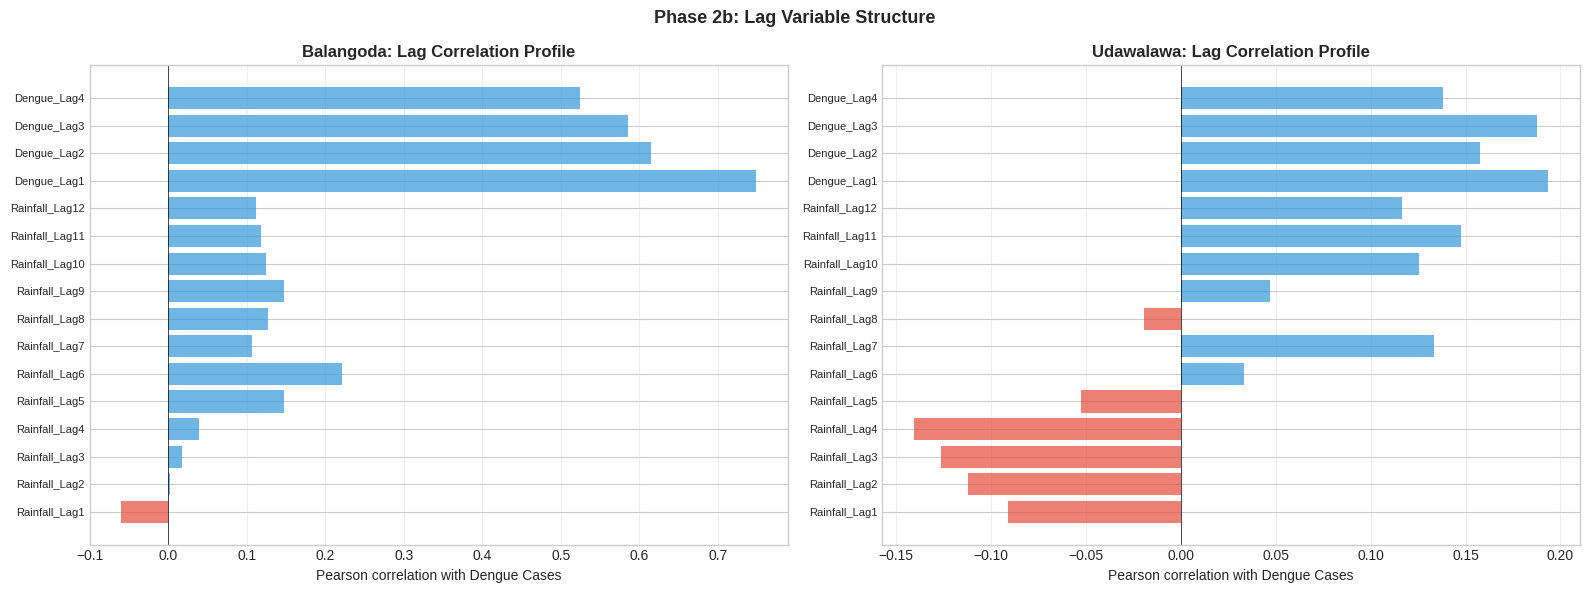

In [8]:
# Correlation heatmap of all lag variables vs dengue cases
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phase 2b: Lag Variable Structure', fontsize=13, fontweight='bold')

rainfall_lags = [f'Rainfall_Lag{i}' for i in range(1, 13)]
dengue_lags = [f'Dengue_Lag{i}' for i in [1,2,3,4]]

for idx, moh in enumerate(sorted(df['MOH'].unique())):
    sub = df[df['MOH']==moh].dropna(subset=rainfall_lags + dengue_lags + ['Dengue_Cases'])
    corr = sub[['Dengue_Cases'] + rainfall_lags + dengue_lags].corr()['Dengue_Cases'].drop('Dengue_Cases')
    colors = ['#E74C3C' if c < 0 else '#3498DB' for c in corr.values]
    axes[idx].barh(range(len(corr)), corr.values, color=colors, alpha=0.7)
    axes[idx].set_yticks(range(len(corr)))
    axes[idx].set_yticklabels(corr.index, fontsize=8)
    axes[idx].set_xlabel('Pearson correlation with Dengue Cases')
    axes[idx].set_title(f'{moh}: Lag Correlation Profile', fontweight='bold')
    axes[idx].axvline(0, color='black', lw=0.5)
    axes[idx].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('phase2b_lag_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

## 2b.9 Save Outputs

In [9]:
df.to_csv('phase2b_output_with_lags.csv', index=False)
print(f'Saved: phase2b_output_with_lags.csv ({len(df):,} records, {len(df.columns)} variables)')

for f in ['phase2b_output_with_lags.csv', 'phase2b_lag_correlations.png']:
    files.download(f)
    print(f'Downloaded: {f}')

Saved: phase2b_output_with_lags.csv (520 records, 30 variables)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: phase2b_output_with_lags.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: phase2b_lag_correlations.png
